# Uplift Modeling / Causal ML — Campanha de Clientes

Este notebook demonstra, com **dados sintéticos**, como estimar quais clientes são mais propensos a **mudar seu comportamento por causa de uma campanha**.

A ideia central é comparar:

- **Modelo de resposta (propensity-style):** quem provavelmente compra?
- **Uplift modeling:** para quem a campanha aumenta a probabilidade de compra?

Será usado um **T-Learner**, uma abordagem de meta-learning causal que treina dois modelos separados: um para clientes tratados e outro para clientes de controle.

> **Importante:** os dados são simulados. O objetivo é aprender a metodologia, não produzir um modelo comercial real.

---

**Nota de revisão (cientista de dados sênior — uplift/causal ML):** esta é uma versão revisada do notebook original. Foram corrigidos alguns problemas metodológicos e adicionadas etapas que faltavam em qualquer projeto sério de uplift. Um resumo das mudanças está no final do notebook, na seção "O que foi corrigido e adicionado nesta revisão".

## 1. Instalação e imports

In [1]:
# Se estiver no Google Colab e alguma biblioteca faltar:
# !pip install scikit-learn pandas numpy matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm, pearsonr, spearmanr

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve

np.random.seed(42)
pd.set_option("display.max_columns", None)

## 2. Criando uma base sintética de clientes

Vamos criar 20.000 clientes com características típicas de uma base comercial:

- idade
- tempo como cliente
- frequência de compras
- recência
- ticket médio
- número de categorias compradas
- desconto médio
- canal digital
- tratamento: recebeu ou não a campanha
- outcome: comprou ou não depois da campanha

Também vamos criar um **efeito causal verdadeiro oculto** nos dados (`uplift_true`). Isso permite comparar o uplift estimado pelo modelo com o efeito que realmente gerou os dados — algo que **nunca temos em um projeto real**, mas que é extremamente útil aqui para validar se a metodologia funciona.

> Nota técnica: como `p_base` e `p_treated` são "clipados" (`clip`) para ficarem em `[0, 1]`, em casos extremos o efeito realmente aplicado pode diferir ligeiramente de `uplift_true`. Isso é irrelevante para o propósito didático do notebook, mas vale saber que `uplift_true` é o efeito *pretendido*, não uma garantia matemática exata em todos os pontos.

In [2]:
n = 20000

df = pd.DataFrame({
    "idade": np.random.randint(18, 76, n),
    "tempo_cliente_meses": np.random.randint(1, 121, n),
    "frequencia_12m": np.random.poisson(8, n).clip(0, 40),
    "recencia_dias": np.random.gamma(2.5, 35, n).clip(1, 365),
    "ticket_medio": np.random.lognormal(mean=np.log(250), sigma=0.65, size=n).clip(30, 3000),
    "categorias_12m": np.random.poisson(3, n).clip(1, 12),
    "desconto_medio": np.random.beta(2, 8, n),
    "canal_digital": np.random.binomial(1, 0.65, n)
})

# Probabilidade base de compra sem campanha
logit_base = (
    -2.2
    + 0.10 * df["frequencia_12m"]
    - 0.008 * df["recencia_dias"]
    + 0.0009 * df["ticket_medio"]
    + 0.12 * df["categorias_12m"]
    + 0.35 * df["canal_digital"]
    + 0.15 * np.log1p(df["tempo_cliente_meses"])
)

p_base = 1 / (1 + np.exp(-logit_base))
p_base = np.clip(p_base, 0.01, 0.90)

# Efeito causal heterogêneo:
# clientes com maior frequência e recência menor respondem melhor à campanha
uplift_true = (
    0.02
    + 0.055 * (df["frequencia_12m"] / 10)
    - 0.00008 * df["recencia_dias"]
    + 0.04 * df["canal_digital"]
    + 0.03 * (1 - df["desconto_medio"])
)

uplift_true = np.clip(uplift_true, -0.05, 0.35)

# Randomização do tratamento: 50% recebem a campanha
df["treatment"] = np.random.binomial(1, 0.5, n)

# Probabilidade final depende do tratamento
p_treated = np.clip(p_base + uplift_true, 0.01, 0.97)
p_outcome = np.where(df["treatment"] == 1, p_treated, p_base)

df["comprou"] = np.random.binomial(1, p_outcome)

# Guardamos o efeito verdadeiro apenas para avaliação didática (oracle)
df["uplift_true"] = uplift_true

# Lista de features usada em todos os modelos deste notebook.
# treatment, comprou e uplift_true ficam de fora propositalmente: são
# tratamento, alvo e "gabarito", nunca features de um modelo preditivo.
features = [
    "idade", "tempo_cliente_meses", "frequencia_12m",
    "recencia_dias", "ticket_medio", "categorias_12m",
    "desconto_medio", "canal_digital"
]

df.head()

,idade,tempo_cliente_meses,frequencia_12m,recencia_dias,ticket_medio,categorias_12m,desconto_medio,canal_digital,treatment,comprou,uplift_true
0,56,63,7,102.908515,519.760639,2,0.427621,1,0,0,0.107439
1,69,61,9,104.032703,146.903481,6,0.043600,0,1,1,0.089869
2,46,120,11,37.256352,181.408716,4,0.124908,0,1,1,0.103772
3,32,105,9,127.425963,185.246416,6,0.268315,0,1,1,0.081256
4,60,34,8,70.851674,320.036849,1,0.540004,1,0,0,0.112132


## 3. Checagem da randomização (balanceamento covariável)

Antes de comparar taxas de compra entre tratamento e controle, um cientista de causal inference **sempre** verifica se a randomização funcionou — ou seja, se as duas populações são de fato comparáveis nas covariáveis observadas.

Aqui a randomização é perfeita por construção (`treatment` sorteado com `p=0.5` independente de `X`), então esperamos **SMD (Standardized Mean Difference) próximo de zero** para todas as variáveis. Um valor de referência comum na literatura é |SMD| < 0.1 como "bem balanceado".

Por que isso importa na prática: se este fosse um dataset **observacional** (ex.: campanha em que o time comercial escolhe quem recebe a oferta), covariáveis desbalanceadas indicariam confundimento — e uma simples diferença de médias entre grupos **não estimaria o efeito causal corretamente**. Seria necessário usar pareamento (matching), ponderação por propensity score (IPW) ou estimadores duplamente robustos.

,variavel,media_tratamento,media_controle,smd
0,categorias_12m,3.051641,3.037045,0.008909
1,recencia_dias,87.020650,87.495509,-0.008673
2,ticket_medio,308.276351,306.930252,0.005994
3,idade,46.585198,46.505024,0.004796
4,desconto_medio,0.199283,0.198884,0.003336
5,tempo_cliente_meses,60.396965,60.458236,-0.001760
6,frequencia_12m,8.008377,8.011063,-0.000953
7,canal_digital,0.652508,0.652086,0.000887


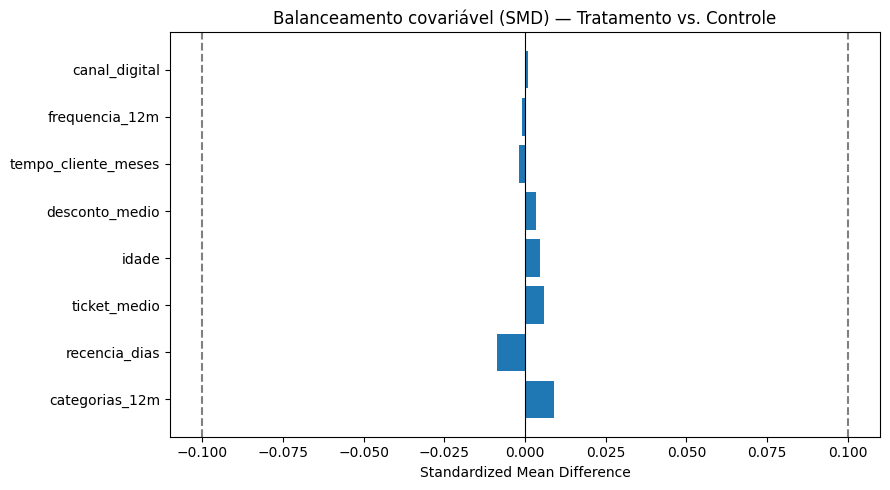

Maior |SMD| observado: 0.009 (OK, dentro do esperado para um experimento randomizado)


In [3]:
def standardized_mean_diff(x_treated, x_control):
    mean_diff = x_treated.mean() - x_control.mean()
    pooled_std = np.sqrt((x_treated.var() + x_control.var()) / 2)
    return mean_diff / pooled_std if pooled_std > 0 else np.nan

balance_rows = []
for col in features:
    x1 = df.loc[df["treatment"] == 1, col]
    x0 = df.loc[df["treatment"] == 0, col]
    balance_rows.append({
        "variavel": col,
        "media_tratamento": x1.mean(),
        "media_controle": x0.mean(),
        "smd": standardized_mean_diff(x1, x0)
    })

balance_table = pd.DataFrame(balance_rows).sort_values(
    "smd", key=np.abs, ascending=False
).reset_index(drop=True)

display(balance_table)

plt.figure(figsize=(9, 5))
colors = ["#d62728" if abs(v) >= 0.1 else "#1f77b4" for v in balance_table["smd"]]
plt.barh(balance_table["variavel"], balance_table["smd"], color=colors)
plt.axvline(0.1, linestyle="--", color="gray")
plt.axvline(-0.1, linestyle="--", color="gray")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Balanceamento covariável (SMD) — Tratamento vs. Controle")
plt.xlabel("Standardized Mean Difference")
plt.tight_layout()
plt.show()

max_smd = balance_table["smd"].abs().max()
print(f"Maior |SMD| observado: {max_smd:.3f} "
      f"({'OK, dentro do esperado para um experimento randomizado' if max_smd < 0.1 else 'ATENÇÃO: possível desbalanceamento'})")

## 4. Conhecendo os dados

In [4]:
print("Shape:", df.shape)
print("\nTratamento:")
print(df["treatment"].value_counts(normalize=True))

print("\nTaxa de compra por grupo:")
print(df.groupby("treatment")["comprou"].mean())

print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

Shape: (20000, 11)

Tratamento:
treatment
1    0.50735
0    0.49265
Name: proportion, dtype: float64

Taxa de compra por grupo:
treatment
0    0.362123
1    0.463684
Name: comprou, dtype: float64

Missing values:


,missing
idade,0
tempo_cliente_meses,0
frequencia_12m,0
recencia_dias,0
ticket_medio,0
categorias_12m,0
desconto_medio,0
canal_digital,0
treatment,0
comprou,0


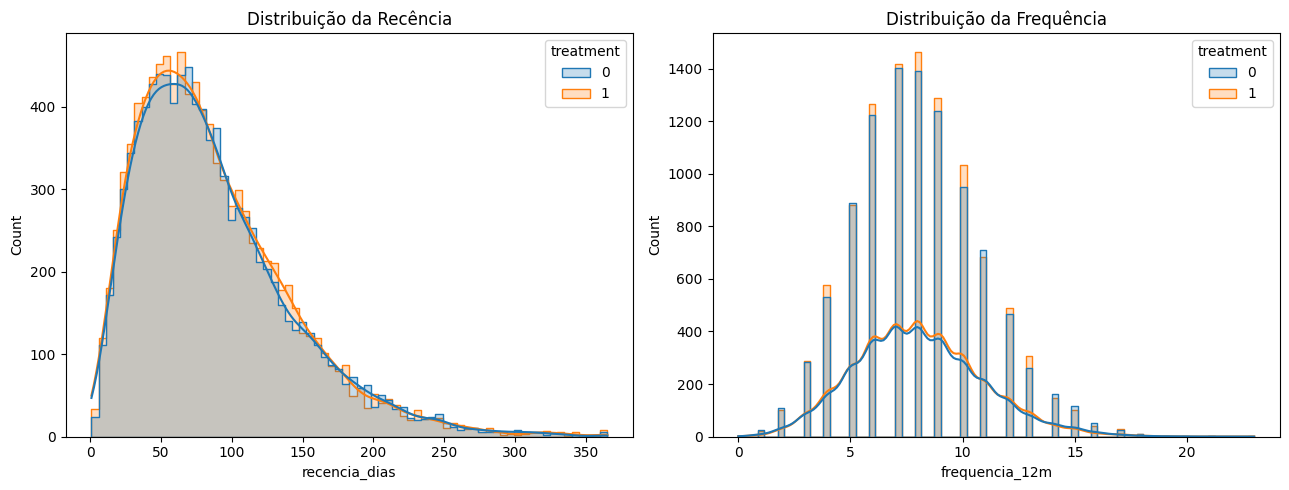

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=df, x="recencia_dias", hue="treatment",
    kde=True, ax=axes[0], element="step"
)
axes[0].set_title("Distribuição da Recência")

sns.histplot(
    data=df, x="frequencia_12m", hue="treatment",
    kde=True, ax=axes[1], element="step"
)
axes[1].set_title("Distribuição da Frequência")

plt.tight_layout()
plt.show()

## 5. Efeito médio da campanha (ATE)

Antes do ML, precisamos entender o efeito agregado.

O **ATE (Average Treatment Effect)**, neste experimento randomizado, pode ser estimado por:

`taxa de compra no tratamento - taxa de compra no controle`

Um ponto que faltava no notebook original: **todo efeito estimado tem incerteza**. Reportar só o ponto estimado sem intervalo de confiança é um erro comum — o "ATE" observado poderia ser ruído amostral. Abaixo calculamos IC 95% e um teste z para a diferença de proporções.

In [6]:
n1 = int((df["treatment"] == 1).sum())
n0 = int((df["treatment"] == 0).sum())

rate_treatment = df.loc[df["treatment"] == 1, "comprou"].mean()
rate_control = df.loc[df["treatment"] == 0, "comprou"].mean()

ate = rate_treatment - rate_control
se_ate = np.sqrt(
    rate_treatment * (1 - rate_treatment) / n1
    + rate_control * (1 - rate_control) / n0
)
z_stat = ate / se_ate
p_value = 2 * (1 - norm.cdf(abs(z_stat)))
ci_low, ci_high = ate - 1.96 * se_ate, ate + 1.96 * se_ate

print(f"Taxa de compra - Tratamento: {rate_treatment:.2%}  (n={n1:,})")
print(f"Taxa de compra - Controle:   {rate_control:.2%}  (n={n0:,})")
print(f"ATE / uplift médio:          {ate:.2%}")
print(f"IC 95%:                      [{ci_low:.2%}, {ci_high:.2%}]")
print(f"z-stat: {z_stat:.2f} | p-valor: {p_value:.2e}")
print(f"\n(para referência: o uplift médio *verdadeiro* simulado é {df['uplift_true'].mean():.2%})")

Taxa de compra - Tratamento: 46.37%  (n=10,147)
Taxa de compra - Controle:   36.21%  (n=9,853)
ATE / uplift médio:          10.16%
IC 95%:                      [8.80%, 11.51%]
z-stat: 14.67 | p-valor: 0.00e+00

(para referência: o uplift médio *verdadeiro* simulado é 10.72%)


## 6. Split treino/teste único

No notebook original, o modelo de propensão usava um split de treino/teste e o T-Learner usava **outro split diferente**. Isso é um problema metodológico: os resultados dos dois modelos deixam de ser diretamente comparáveis, e fica fácil, sem perceber, misturar dados de treino de um modelo com dados de teste de outro.

A partir daqui, usamos **um único split**, estratificado por `treatment` (para preservar a proporção 50/50 em treino e teste), reutilizado em todas as seções seguintes.

In [7]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.30,
    random_state=42,
    stratify=df["treatment"]
)

train = df.loc[train_idx].copy()
test = df.loc[test_idx].copy()

print(f"Treino: {len(train):,} clientes | Teste: {len(test):,} clientes")
print(train["treatment"].value_counts(normalize=True))

Treino: 14,000 clientes | Teste: 6,000 clientes
treatment
1    0.507357
0    0.492643
Name: proportion, dtype: float64


## 7. Modelo de resposta ("propensão" no sentido de marketing)

Primeiro vamos fazer algo que seria comum em um projeto de ML tradicional:

> prever a probabilidade de compra usando apenas características do cliente.

O tratamento **não entra como feature** aqui. O objetivo é mostrar que alta probabilidade de compra não significa necessariamente alto impacto da campanha.

**Correção de terminologia importante:** o notebook original chamava isso de "modelo de propensão" / `propensity_score`. Em causal inference, **propensity score** tem um significado técnico específico: `e(X) = P(Treatment = 1 | X)`, a probabilidade de receber o tratamento dado X — usado para pareamento, IPW e checagem de overlap em estudos observacionais. O que estamos treinando aqui é, na verdade, um **modelo de resposta** (`P(Y=1 | X)`, sem olhar o tratamento). São coisas diferentes, e confundi-las é um erro comum. Mais abaixo estimamos o propensity score de verdade, só para ilustrar a diferença.

Também removemos `class_weight="balanced"` do Random Forest: essa opção reponta as classes para melhorar métricas como recall/F1, mas **distorce a probabilidade prevista** (ela deixa de ser uma estimativa calibrada de `P(Y=1|X)`). Isso é péssimo para uplift: como o uplift é uma **diferença de probabilidades**, qualquer viés de calibração se propaga direto para a estimativa do efeito causal.

In [8]:
logreg_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
logreg_baseline.fit(train[features], train["comprou"])

response_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=30,
    random_state=42,
    n_jobs=-1
    # sem class_weight="balanced" -> queremos probabilidades calibradas,
    # não uma acurácia balanceada entre classes
)
response_model.fit(train[features], train["comprou"])

test["resposta_logreg"] = logreg_baseline.predict_proba(test[features])[:, 1]
test["resposta_rf"] = response_model.predict_proba(test[features])[:, 1]

auc_logreg = roc_auc_score(test["comprou"], test["resposta_logreg"])
auc_rf = roc_auc_score(test["comprou"], test["resposta_rf"])

print(f"ROC-AUC - Regressão Logística: {auc_logreg:.3f}")
print(f"ROC-AUC - Random Forest:       {auc_rf:.3f}")

ROC-AUC - Regressão Logística: 0.665
ROC-AUC - Random Forest:       0.659


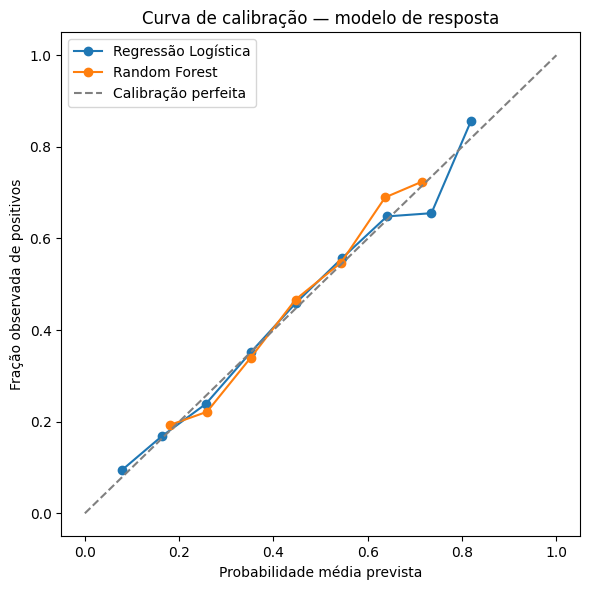

In [9]:
frac_pos_lr, mean_pred_lr = calibration_curve(test["comprou"], test["resposta_logreg"], n_bins=10)
frac_pos_rf, mean_pred_rf = calibration_curve(test["comprou"], test["resposta_rf"], n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(mean_pred_lr, frac_pos_lr, marker="o", label="Regressão Logística")
plt.plot(mean_pred_rf, frac_pos_rf, marker="o", label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibração perfeita")
plt.xlabel("Probabilidade média prevista")
plt.ylabel("Fração observada de positivos")
plt.title("Curva de calibração — modelo de resposta")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Propensity score de verdade: e(X) = P(Treatment = 1 | X)
# Como o tratamento foi sorteado com p=0.5 independente de X, e(X) deveria
# ficar em torno de 0.50 para todo mundo -> não há confundimento a corrigir.
# Em uma campanha real, não randomizada, e(X) varia com X e é essencial
# para matching / IPW / checagem de overlap.
propensity_score_model = LogisticRegression(max_iter=1000, random_state=42)
propensity_score_model.fit(train[features], train["treatment"])
e_hat = propensity_score_model.predict_proba(test[features])[:, 1]

print("Propensity score estimado e(X) (deve ficar perto de 0.50, pois o tratamento é randomizado):")
print(f"  média: {e_hat.mean():.3f} | min: {e_hat.min():.3f} | max: {e_hat.max():.3f}")

Propensity score estimado e(X) (deve ficar perto de 0.50, pois o tratamento é randomizado):
  média: 0.508 | min: 0.480 | max: 0.541


## 8. Por que um modelo de resposta não é suficiente?

Vamos olhar os clientes com maior probabilidade de resposta.

Um cliente pode ter 90% de chance de comprar **mesmo sem receber a campanha**. Nesse caso, gastar dinheiro para convencê-lo tem pouco valor incremental.

O uplift tenta estimar:

`P(compra | tratamento, X) - P(compra | controle, X)`

## 9. Uplift Modeling com T-Learner

O T-Learner cria dois modelos:

**Modelo T (tratamento):**

`X → P(Y=1 | T=1, X)`

**Modelo C (controle):**

`X → P(Y=1 | T=0, X)`

Depois:

`Uplift = P(Y=1 | T=1, X) - P(Y=1 | T=0, X)`

O resultado é uma estimativa do **CATE (Conditional Average Treatment Effect)** para cada cliente.

Usamos o mesmo `train`/`test` definido na Seção 6, e novamente **sem** `class_weight="balanced"`, pelo mesmo motivo de calibração explicado acima. O T-Learner é o meta-learner mais simples que existe; ele tem uma fraqueza conhecida: os dois modelos são treinados de forma totalmente independente, em amostras de tamanhos diferentes (aqui parecidos, pois é 50/50, mas em campanhas reais o grupo tratado costuma ser muito menor), o que pode gerar regularização diferente entre eles e viesar a diferença. Voltamos a esse ponto na Seção 16 (X-Learner).

In [11]:
treated_train = train[train["treatment"] == 1]
control_train = train[train["treatment"] == 0]

model_t = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

model_c = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

model_t.fit(treated_train[features], treated_train["comprou"])
model_c.fit(control_train[features], control_train["comprou"])

p1 = model_t.predict_proba(test[features])[:, 1]
p0 = model_c.predict_proba(test[features])[:, 1]

test["p_treatment"] = p1
test["p_control"] = p0
test["uplift"] = test["p_treatment"] - test["p_control"]

test[["p_treatment", "p_control", "uplift"]].head(10)

,p_treatment,p_control,uplift
16965,0.555287,0.440712,0.114575
14991,0.517600,0.395281,0.122319
13451,0.436895,0.333927,0.102968
10711,0.526599,0.348558,0.178041
1172,0.595959,0.471195,0.124764
7291,0.492778,0.432093,0.060684
12271,0.469011,0.345718,0.123293
3620,0.341189,0.338266,0.002923
9260,0.371960,0.243111,0.128849
4186,0.523463,0.346387,0.177075


ROC-AUC modelo T (tratados):  0.669
ROC-AUC modelo C (controle):  0.636


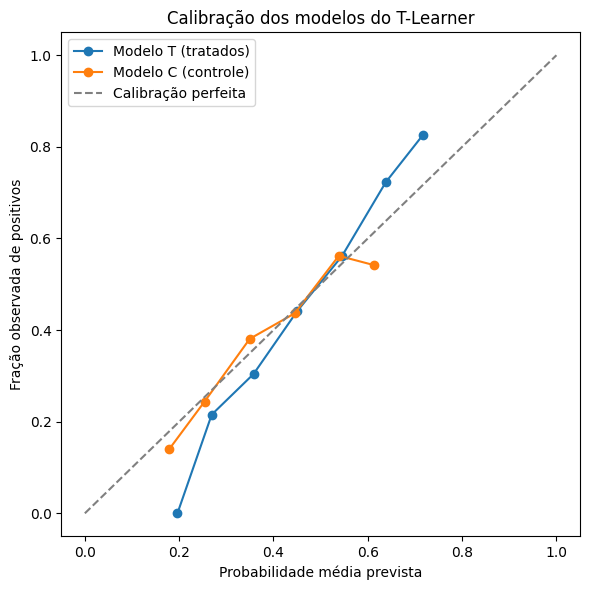

In [12]:
# Checagem rápida de calibração dos dois modelos do T-Learner, cada um
# avaliado apenas no braço de teste correspondente (tratado / controle)
test_treated = test[test["treatment"] == 1]
test_control = test[test["treatment"] == 0]

auc_model_t = roc_auc_score(test_treated["comprou"], test_treated["p_treatment"])
auc_model_c = roc_auc_score(test_control["comprou"], test_control["p_control"])

print(f"ROC-AUC modelo T (tratados):  {auc_model_t:.3f}")
print(f"ROC-AUC modelo C (controle):  {auc_model_c:.3f}")

frac_pos_t, mean_pred_t = calibration_curve(test_treated["comprou"], test_treated["p_treatment"], n_bins=10)
frac_pos_c, mean_pred_c = calibration_curve(test_control["comprou"], test_control["p_control"], n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(mean_pred_t, frac_pos_t, marker="o", label="Modelo T (tratados)")
plt.plot(mean_pred_c, frac_pos_c, marker="o", label="Modelo C (controle)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibração perfeita")
plt.xlabel("Probabilidade média prevista")
plt.ylabel("Fração observada de positivos")
plt.title("Calibração dos modelos do T-Learner")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Ranking dos clientes por uplift

In [13]:
ranking = test.sort_values("uplift", ascending=False).copy()

ranking[[
    "idade", "frequencia_12m", "recencia_dias",
    "ticket_medio", "p_treatment", "p_control", "uplift"
]].head(20)

,idade,frequencia_12m,recencia_dias,ticket_medio,p_treatment,p_control,uplift
7804,26,10,146.762659,143.219013,0.568104,0.250818,0.317286
11695,34,9,140.380002,154.931047,0.503993,0.222502,0.281491
7895,25,9,109.015411,162.402345,0.572022,0.299363,0.272659
19190,30,11,160.822284,88.836615,0.525466,0.260073,0.265393
10457,35,10,229.794891,116.042896,0.476122,0.216731,0.259391
7094,64,7,18.224814,185.390168,0.506491,0.247710,0.258781
9715,36,11,88.790331,182.851412,0.536825,0.283014,0.253811
9572,60,7,21.112015,197.107201,0.523337,0.270341,0.252997
17557,39,7,66.188879,272.073048,0.492436,0.246355,0.246080
14240,25,11,142.081562,309.588862,0.587813,0.342856,0.244957


## 11. Segmentando os clientes

Uma interpretação prática do uplift é dividir os clientes em quatro grupos (framework clássico de uplift):

1. **Persuadíveis:** baixa probabilidade sem campanha e alto ganho com tratamento.
2. **Certos:** comprariam de qualquer maneira (alta probabilidade em ambos os cenários).
3. **Perdidos:** baixa probabilidade nos dois cenários.
4. **Não perturbar (Sleeping Dogs):** a campanha reduz a probabilidade de compra.

**Bug corrigido:** a função original usava thresholds fixos (`uplift >= 0.08`, `p_control < 0.65`) que, na ordem em que as condições eram checadas, podiam classificar como "Certo" um cliente com uplift alto só porque `p_control` também era alto — mesmo que a campanha estivesse gerando bastante incremento nele. Abaixo os grupos são mutuamente exclusivos por construção (uplift negativo sempre vira "Não perturbar" primeiro) e os thresholds de propensão são definidos a partir dos **percentis da própria base de teste** (tercis), em vez de valores fixos que não generalizam para outra base ou outro produto.

In [14]:
def build_uplift_segments(data, low_q=0.33, high_q=0.67):
    low_thresh = data["p_control"].quantile(low_q)
    high_thresh = data["p_control"].quantile(high_q)

    def _classify(row):
        if row["uplift"] < 0:
            return "Não perturbar (Sleeping Dogs)"
        if row["p_control"] >= high_thresh:
            return "Certo (compra de qualquer forma)"
        if row["p_control"] < low_thresh and row["p_treatment"] < low_thresh:
            return "Perdido (não compra de qualquer forma)"
        return "Persuadível"

    segments = data.apply(_classify, axis=1)
    thresholds = {"low_thresh": low_thresh, "high_thresh": high_thresh}
    return segments, thresholds

test["segmento_uplift"], thresholds_seg = build_uplift_segments(test)

print(f"Thresholds usados (percentis de p_control): {thresholds_seg}")
print()
print(test["segmento_uplift"].value_counts())

Thresholds usados (percentis de p_control): {'low_thresh': np.float64(0.3064543481566023), 'high_thresh': np.float64(0.4040037077650873)}

segmento_uplift
Persuadível                               3578
Certo (compra de qualquer forma)          1914
Perdido (não compra de qualquer forma)     411
Não perturbar (Sleeping Dogs)               97
Name: count, dtype: int64


In [15]:
# Como os dados são sintéticos, podemos conferir a qualidade da segmentação
# contra o efeito causal REAL (uplift_true) -- algo que não existe em produção,
# mas que serve aqui como um teste de sanidade da metodologia.
segment_summary = (
    test.groupby("segmento_uplift")
    .agg(
        clientes=("uplift", "size"),
        uplift_previsto_medio=("uplift", "mean"),
        uplift_real_medio_oracle=("uplift_true", "mean"),
        propensao_com_campanha=("p_treatment", "mean"),
        propensao_sem_campanha=("p_control", "mean")
    )
    .sort_values("uplift_previsto_medio", ascending=False)
)

segment_summary

,clientes,uplift_previsto_medio,uplift_real_medio_oracle,propensao_com_campanha,propensao_sem_campanha
segmento_uplift,,,,,
Persuadível,3578,0.116346,0.101158,0.428518,0.312172
Certo (compra de qualquer forma),1914,0.091580,0.125142,0.572606,0.481026
Perdido (não compra de qualquer forma),411,0.069084,0.075337,0.274222,0.205138
Não perturbar (Sleeping Dogs),97,-0.017055,0.090486,0.412582,0.429636


## 12. Comparando modelo de resposta e uplift

Agora podemos enxergar a diferença conceitual:

- **Modelo de resposta:** prioriza quem provavelmente compra.
- **Uplift:** prioriza quem provavelmente muda seu comportamento por causa da campanha.

Em um projeto real, a segunda abordagem pode reduzir desperdício de campanhas em clientes que comprariam de qualquer maneira.

(Correção: o notebook original chamava esses grupos de "quartil", mas `pd.qcut(..., 10, ...)` gera **decis**, não quartis. Corrigido abaixo.)

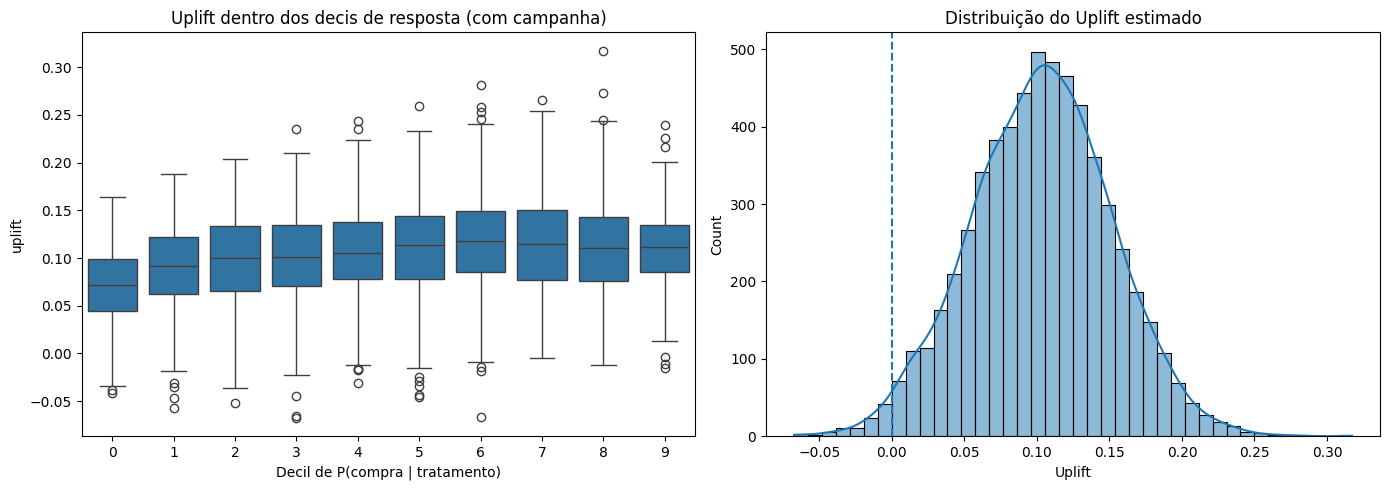

In [16]:
comparison = test.copy()

comparison["decil_resposta_tratamento"] = pd.qcut(
    comparison["p_treatment"], 10, labels=False, duplicates="drop"
)

comparison["decil_uplift"] = pd.qcut(
    comparison["uplift"], 10, labels=False, duplicates="drop"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=comparison,
    x="decil_resposta_tratamento",
    y="uplift",
    ax=axes[0]
)
axes[0].set_title("Uplift dentro dos decis de resposta (com campanha)")
axes[0].set_xlabel("Decil de P(compra | tratamento)")

sns.histplot(
    comparison["uplift"],
    bins=40,
    kde=True,
    ax=axes[1]
)
axes[1].axvline(0, linestyle="--")
axes[1].set_title("Distribuição do Uplift estimado")
axes[1].set_xlabel("Uplift")

plt.tight_layout()
plt.show()

## 13. Avaliação do ranking de uplift por decis (com intervalo de confiança)

Como não observamos simultaneamente o resultado tratado e não tratado para o mesmo cliente, não podemos calcular o uplift individual diretamente a partir dos dados observados.

Mas, como estamos trabalhando com um experimento randomizado, podemos avaliar o ranking por grupos: ordenamos os clientes pelo uplift previsto, dividimos em decis e comparamos, dentro de cada decil, a taxa de compra de quem foi tratado contra a de quem ficou no controle.

**Adição importante:** o notebook original reportava só o ponto estimado por decil. Com poucas centenas de clientes por braço em cada decil, essa diferença de proporções é ruidosa — por isso adicionamos um **intervalo de confiança de 95%** (aproximação normal para diferença de duas proporções). Também incluímos, só para conferência pedagógica, o uplift **real** (`uplift_true`) de cada decil — isso só é possível porque os dados são sintéticos.

In [17]:
eval_df = test.sort_values("uplift", ascending=False).reset_index(drop=True)

eval_df["rank"] = np.arange(1, len(eval_df) + 1)
eval_df["decile"] = pd.qcut(
    eval_df["rank"],
    10,
    labels=[f"D{i}" for i in range(1, 11)]
)

z95 = norm.ppf(0.975)
rows = []

for decile, group in eval_df.groupby("decile", observed=False):
    treated = group[group["treatment"] == 1]
    control = group[group["treatment"] == 0]
    n1, n0 = len(treated), len(control)

    if n1 > 0 and n0 > 0:
        p1 = treated["comprou"].mean()
        p0 = control["comprou"].mean()
        observed_uplift = p1 - p0
        se = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
        ci_low, ci_high = observed_uplift - z95 * se, observed_uplift + z95 * se
    else:
        observed_uplift = ci_low = ci_high = np.nan

    rows.append({
        "decile": decile,
        "clientes": len(group),
        "uplift_previsto": group["uplift"].mean(),
        "uplift_real_oracle": group["uplift_true"].mean(),
        "uplift_observado": observed_uplift,
        "ci95_low": ci_low,
        "ci95_high": ci_high
    })

decile_results = pd.DataFrame(rows)
decile_results

,decile,clientes,uplift_previsto,uplift_real_oracle,uplift_observado,ci95_low,ci95_high
0,D1,600,0.187341,0.112259,0.055672,-0.023830,0.135175
1,D2,600,0.152902,0.109375,0.017635,-0.061863,0.097132
2,D3,600,0.135634,0.110086,0.055536,-0.023201,0.134273
3,D4,600,0.122050,0.109491,0.077342,-0.001236,0.155920
4,D5,600,0.109643,0.108186,0.107119,0.028074,0.186164
5,D6,600,0.097865,0.106112,0.069130,-0.008512,0.146772
6,D7,600,0.084984,0.107124,0.095890,0.018450,0.173330
7,D8,600,0.070302,0.104774,0.179310,0.101956,0.256664
8,D9,600,0.052607,0.102638,0.058886,-0.019234,0.137006
9,D10,600,0.017184,0.098630,0.188034,0.111170,0.264898


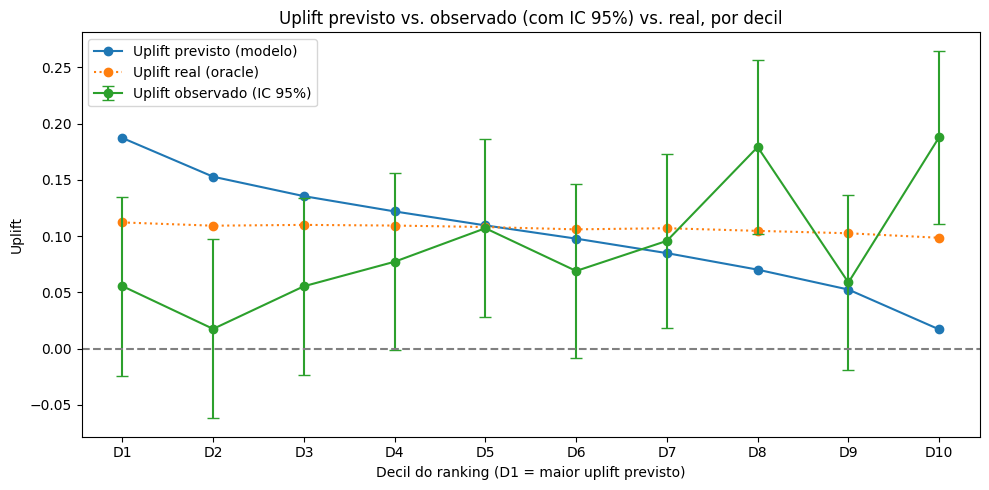

In [18]:
plt.figure(figsize=(10, 5))

x_labels = decile_results["decile"].astype(str)

plt.plot(x_labels, decile_results["uplift_previsto"], marker="o", label="Uplift previsto (modelo)")
plt.plot(x_labels, decile_results["uplift_real_oracle"], marker="o", linestyle=":", label="Uplift real (oracle)")

yerr = np.vstack([
    decile_results["uplift_observado"] - decile_results["ci95_low"],
    decile_results["ci95_high"] - decile_results["uplift_observado"]
])
plt.errorbar(
    x_labels, decile_results["uplift_observado"],
    yerr=yerr, fmt="o-", capsize=4, label="Uplift observado (IC 95%)"
)

plt.axhline(0, linestyle="--", color="gray")
plt.title("Uplift previsto vs. observado (com IC 95%) vs. real, por decil")
plt.xlabel("Decil do ranking (D1 = maior uplift previsto)")
plt.ylabel("Uplift")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Avaliação oracle — comparação direta com o efeito causal verdadeiro

Esta seção só é possível porque os dados são sintéticos: temos `uplift_true`, o efeito causal individual que de fato gerou os dados. Em um projeto real **nunca temos isso** (é o problema fundamental da inferência causal — o contrafactual nunca é observado para o mesmo indivíduo). Mas para *validar a metodologia em si* — antes de confiar nela em produção — comparar contra um "gabarito" sintético é exatamente o tipo de teste que vale a pena fazer neste tipo de notebook de estudo/PoC.

In [19]:
corr_pearson, _ = pearsonr(test["uplift"], test["uplift_true"])
corr_spearman, _ = spearmanr(test["uplift"], test["uplift_true"])
mae = (test["uplift"] - test["uplift_true"]).abs().mean()
bias = (test["uplift"] - test["uplift_true"]).mean()

print(f"Correlação de Pearson (uplift previsto x uplift real):  {corr_pearson:.3f}")
print(f"Correlação de Spearman (concordância de ranking):       {corr_spearman:.3f}")
print(f"MAE (erro absoluto médio):                              {mae:.4f}")
print(f"Viés médio (previsto - real):                           {bias:+.4f}")

Correlação de Pearson (uplift previsto x uplift real):  0.154
Correlação de Spearman (concordância de ranking):       0.130
MAE (erro absoluto médio):                              0.0410
Viés médio (previsto - real):                           -0.0038


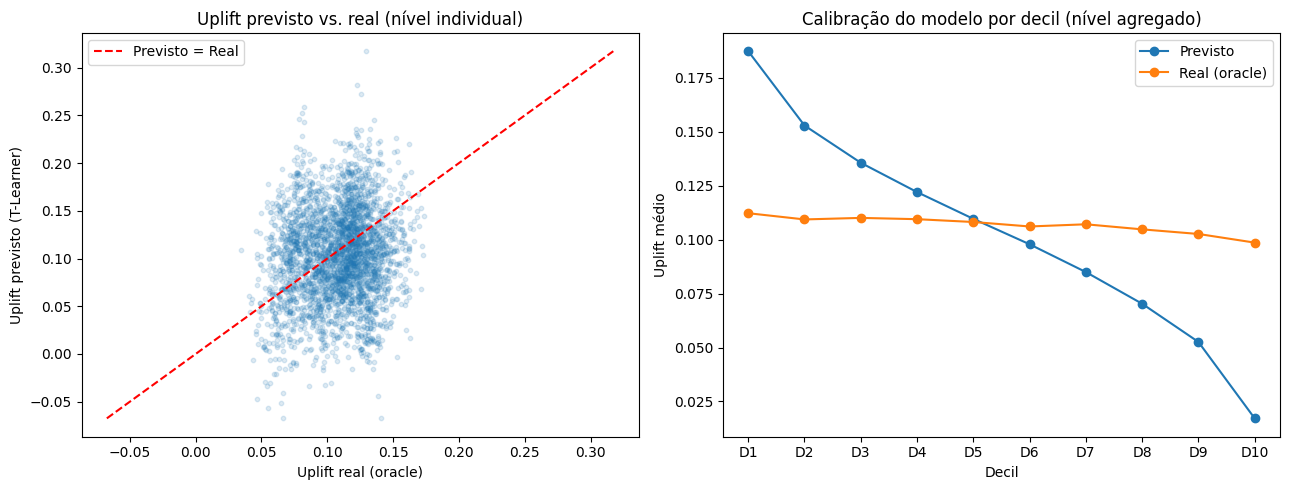

Padrão típico de uplift modeling: a correlação em nível INDIVIDUAL costuma ser moderada (o problema é estatisticamente difícil), mas a calibração em nível de DECIL tende a ser muito melhor — e é o que importa para decidir quem priorizar em uma campanha.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample = test.sample(min(3000, len(test)), random_state=42)
axes[0].scatter(sample["uplift_true"], sample["uplift"], alpha=0.15, s=10)
lims = [
    min(sample["uplift_true"].min(), sample["uplift"].min()),
    max(sample["uplift_true"].max(), sample["uplift"].max())
]
axes[0].plot(lims, lims, linestyle="--", color="red", label="Previsto = Real")
axes[0].set_xlabel("Uplift real (oracle)")
axes[0].set_ylabel("Uplift previsto (T-Learner)")
axes[0].set_title("Uplift previsto vs. real (nível individual)")
axes[0].legend()

axes[1].plot(decile_results["decile"].astype(str), decile_results["uplift_previsto"], marker="o", label="Previsto")
axes[1].plot(decile_results["decile"].astype(str), decile_results["uplift_real_oracle"], marker="o", label="Real (oracle)")
axes[1].set_title("Calibração do modelo por decil (nível agregado)")
axes[1].set_xlabel("Decil")
axes[1].set_ylabel("Uplift médio")
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    "Padrão típico de uplift modeling: a correlação em nível INDIVIDUAL costuma ser "
    "moderada (o problema é estatisticamente difícil), mas a calibração em nível de "
    "DECIL tende a ser muito melhor — e é o que importa para decidir quem priorizar "
    "em uma campanha."
)

## 15. Curva de Qini e AUUC

A curva de Qini é o padrão de mercado para avaliar modelos de uplift (o notebook original listava isso em "próximos passos" mas não implementava). A ideia:

1. Ordenamos os clientes pelo uplift previsto, do maior para o menor.
2. Para cada fração `t` da base, calculamos o ganho incremental acumulado, corrigindo pelo tamanho dos grupos tratado/controle dentro dessa fração:

`g(t) = Y_tratado(t) - Y_controle(t) * (n_tratado(t) / n_controle(t))`

3. Comparamos a curva do modelo com a curva de um direcionamento **aleatório** (linha reta entre 0 e o ganho total). A área entre as duas curvas é o **Qini coefficient** (equivalente ao AUUC nesta formulação): quanto maior, melhor o modelo separa quem responde bem da campanha de quem não responde.

**Atenção:** um Qini coefficient calculado sobre um único holdout é, ele mesmo, uma estatística ruidosa — assim como o ATE e o uplift por decil das seções anteriores. Um valor baixo ou até negativo não significa necessariamente "o código está errado"; pode significar que, *neste holdout específico*, o modelo não conseguiu separar bem os grupos, ou que o sinal de heterogeneidade real é sutil demais para esse tamanho de amostra. Por isso, logo abaixo, testamos a significância estatística do Qini coefficient com um teste de permutação — o mesmo item que estava listado como "próximo passo" no notebook original.

In [21]:
def qini_curve(data, uplift_col, outcome_col="comprou", treatment_col="treatment"):
    data_sorted = data.sort_values(uplift_col, ascending=False).reset_index(drop=True)
    n = len(data_sorted)

    is_treated = (data_sorted[treatment_col] == 1).astype(float)
    is_control = (data_sorted[treatment_col] == 0).astype(float)

    cum_treated = is_treated.cumsum()
    cum_control = is_control.cumsum()
    cum_y_treated = (data_sorted[outcome_col] * is_treated).cumsum()
    cum_y_control = (data_sorted[outcome_col] * is_control).cumsum()

    ratio = np.where(cum_control > 0, cum_treated / cum_control.replace(0, np.nan), 0)
    ratio = np.nan_to_num(ratio, nan=0.0)

    qini_values = (cum_y_treated - cum_y_control * ratio).to_numpy()
    fraction = np.arange(1, n + 1) / n

    fraction = np.insert(fraction, 0, 0.0)
    qini_values = np.insert(qini_values, 0, 0.0)
    return fraction, qini_values


def qini_auc(fraction, qini_values):
    # Integração trapezoidal manual (evita depender de np.trapz/np.trapezoid,
    # cujo nome mudou entre versões do NumPy)
    return np.sum(
        (fraction[1:] - fraction[:-1]) * (qini_values[1:] + qini_values[:-1]) / 2
    )


frac_model, qini_model = qini_curve(test, "uplift")
frac_oracle, qini_oracle = qini_curve(test, "uplift_true")

frac_random = np.array([0.0, 1.0])
qini_random = np.array([0.0, qini_model[-1]])

auc_model = qini_auc(frac_model, qini_model)
auc_oracle = qini_auc(frac_oracle, qini_oracle)
auc_random = qini_auc(frac_random, qini_random)

qini_coefficient_t = auc_model - auc_random
qini_coefficient_oracle = auc_oracle - auc_random

print(f"Qini coefficient (T-Learner):             {qini_coefficient_t:,.2f}")
print(f"Qini coefficient (oracle, teto teórico):   {qini_coefficient_oracle:,.2f}")
print(
    "\n(o oracle usa uplift_true para ordenar -- é o melhor resultado possível "
    "neste holdout, e só existe porque os dados são sintéticos. O quanto o "
    "T-Learner se aproxima dele é avaliado com rigor estatístico na próxima célula.)"
)

Qini coefficient (T-Learner):             -33.89
Qini coefficient (oracle, teto teórico):   33.50

(o oracle usa uplift_true para ordenar -- é o melhor resultado possível neste holdout, e só existe porque os dados são sintéticos. O quanto o T-Learner se aproxima dele é avaliado com rigor estatístico na próxima célula.)


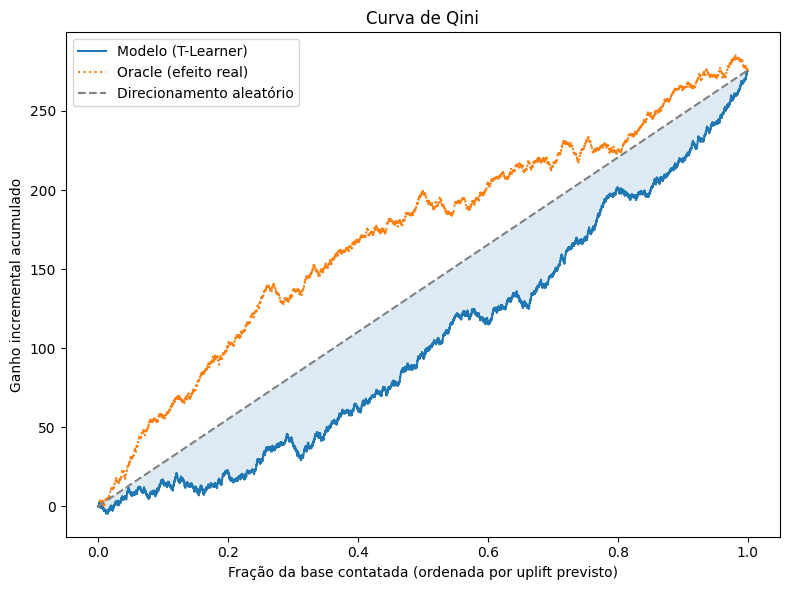

In [22]:
plt.figure(figsize=(8, 6))
plt.plot(frac_model, qini_model, label="Modelo (T-Learner)")
plt.plot(frac_oracle, qini_oracle, linestyle=":", label="Oracle (efeito real)")
plt.plot(frac_random, qini_random, linestyle="--", color="gray", label="Direcionamento aleatório")
plt.fill_between(frac_model, qini_model, np.interp(frac_model, frac_random, qini_random), alpha=0.15)
plt.xlabel("Fração da base contatada (ordenada por uplift previsto)")
plt.ylabel("Ganho incremental acumulado")
plt.title("Curva de Qini")
plt.legend()
plt.tight_layout()
plt.show()

### 15.1 O Qini coefficient é estatisticamente melhor que aleatório?

Fazemos um **teste de permutação**: embaralhamos a coluna de uplift previsto (quebrando de propósito qualquer relação com o resultado real), recalculamos o Qini coefficient centenas de vezes, e comparamos o valor observado com essa distribuição nula. Isso responde à pergunta certa — não "o número deu positivo?", mas "esse número é maior do que eu esperaria só por acaso, com este tamanho de amostra?".

Qini coefficient observado (T-Learner):        -33.89
Distribuição nula (aleatória): média=0.09, desvio=9.74
p-valor (H0: modelo = direcionamento aleatório): 1.000

-> Neste holdout, não há evidência estatística suficiente de que o T-Learner supere um direcionamento aleatório. Isso NÃO significa que não exista heterogeneidade real (a Seção 14 mostra que existe, via uplift_true) -- significa que este modelo, com estes dados e este tamanho de amostra, não a captura de forma confiável. Na prática, é exatamente esse tipo de resultado que deveria bloquear o deploy de um modelo de uplift, mesmo que a métrica pareça 'ok' à primeira vista.


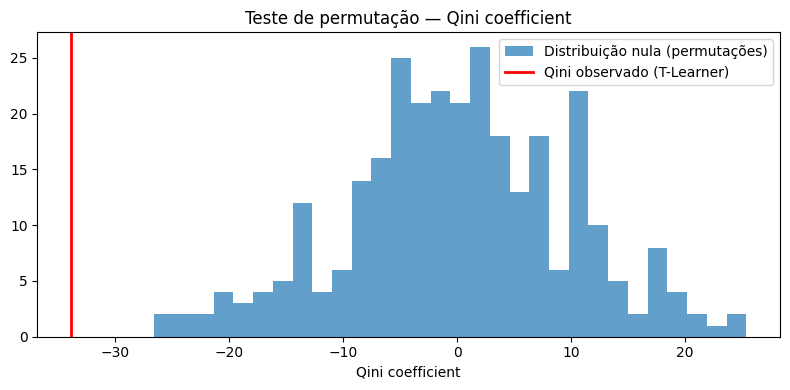

In [23]:
def qini_permutation_pvalue(data, score_col, auc_random_ref, n_permutations=300,
                             outcome_col="comprou", treatment_col="treatment", random_state=42):
    rng = np.random.default_rng(random_state)
    values = data[score_col].to_numpy()

    obs_frac, obs_qini = qini_curve(data, score_col, outcome_col, treatment_col)
    observed_coef = qini_auc(obs_frac, obs_qini) - auc_random_ref

    shuffled = data.copy()
    null_coefs = np.empty(n_permutations)
    for i in range(n_permutations):
        shuffled[score_col] = rng.permutation(values)
        frac_p, qini_p = qini_curve(shuffled, score_col, outcome_col, treatment_col)
        null_coefs[i] = qini_auc(frac_p, qini_p) - auc_random_ref

    # +1 / +1 (correção de continuidade): nunca reportar p-valor = 0
    p_value = (np.sum(null_coefs >= observed_coef) + 1) / (n_permutations + 1)
    return observed_coef, null_coefs, p_value


obs_coef_t, null_coefs_t, p_value_t = qini_permutation_pvalue(test, "uplift", auc_random)

print(f"Qini coefficient observado (T-Learner):        {obs_coef_t:,.2f}")
print(f"Distribuição nula (aleatória): média={null_coefs_t.mean():,.2f}, desvio={null_coefs_t.std():,.2f}")
print(f"p-valor (H0: modelo = direcionamento aleatório): {p_value_t:.3f}")

if p_value_t < 0.05:
    print("\n-> O modelo separa os grupos de forma estatisticamente melhor que o acaso neste holdout.")
else:
    print(
        "\n-> Neste holdout, não há evidência estatística suficiente de que o T-Learner "
        "supere um direcionamento aleatório. Isso NÃO significa que não exista heterogeneidade "
        "real (a Seção 14 mostra que existe, via uplift_true) -- significa que este modelo, "
        "com estes dados e este tamanho de amostra, não a captura de forma confiável. "
        "Na prática, é exatamente esse tipo de resultado que deveria bloquear o deploy de um "
        "modelo de uplift, mesmo que a métrica pareça 'ok' à primeira vista."
    )

plt.figure(figsize=(8, 4))
plt.hist(null_coefs_t, bins=30, alpha=0.7, label="Distribuição nula (permutações)")
plt.axvline(obs_coef_t, color="red", linewidth=2, label="Qini observado (T-Learner)")
plt.title("Teste de permutação — Qini coefficient")
plt.xlabel("Qini coefficient")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Simulação de targeting

> Antes de ler os números abaixo em valor absoluto, olhe o p-valor da Seção 15.1: se o Qini coefficient não for estatisticamente diferente de aleatório, a comparação de efeito incremental abaixo também deve ser lida com a mesma cautela — ela usa exatamente o mesmo ranking de uplift, no mesmo holdout.

Vamos comparar uma estratégia baseada em resposta com uma estratégia baseada em uplift.

A pergunta é:

> Se eu só puder abordar 20% da minha base, qual estratégia encontra mais efeito incremental?

A estratégia de resposta seleciona os clientes com maior probabilidade de compra sob tratamento.

A estratégia de uplift seleciona os clientes com maior efeito incremental estimado.

In [24]:
target_fraction = 0.20
k = int(len(test) * target_fraction)

resposta_target = test.nlargest(k, "p_treatment").copy()
uplift_target = test.nlargest(k, "uplift").copy()

def observed_incremental_effect(group):
    treated = group[group["treatment"] == 1]
    control = group[group["treatment"] == 0]

    if len(treated) == 0 or len(control) == 0:
        return np.nan, np.nan

    p1, p0 = treated["comprou"].mean(), control["comprou"].mean()
    effect = p1 - p0
    se = np.sqrt(p1 * (1 - p1) / len(treated) + p0 * (1 - p0) / len(control))
    return effect, 1.96 * se

resposta_effect, resposta_ci = observed_incremental_effect(resposta_target)
uplift_effect, uplift_ci = observed_incremental_effect(uplift_target)

print(f"Clientes selecionados: {k:,} ({target_fraction:.0%} da base de teste)")
print(f"Uplift observado - targeting por resposta: {resposta_effect:.2%} (+/- {resposta_ci:.2%})")
print(f"Uplift observado - targeting por uplift:   {uplift_effect:.2%} (+/- {uplift_ci:.2%})")

Clientes selecionados: 1,200 (20% da base de teste)
Uplift observado - targeting por resposta: 13.11% (+/- 5.47%)
Uplift observado - targeting por uplift:   3.65% (+/- 5.62%)


## 17. Valor financeiro da campanha

Uma aplicação de negócio precisa considerar custo e receita.

Suponha:

- margem média incremental por compra: R$ 250
- custo da campanha por cliente: R$ 10

Podemos estimar um valor incremental aproximado:

`clientes alvo × uplift × margem - custo da campanha`

Esta é uma simplificação didática. Em uma aplicação real, seria necessário considerar margem real, custos variáveis, descontos, capacidade comercial e outros fatores.

In [25]:
margem_incremental = 250
custo_campanha = 10

def estimated_campaign_value(target):
    incremental_sales = target["uplift"].clip(lower=0).sum()
    revenue_value = incremental_sales * margem_incremental
    campaign_cost = len(target) * custo_campanha
    return revenue_value - campaign_cost

value_resposta = estimated_campaign_value(resposta_target)
value_uplift = estimated_campaign_value(uplift_target)

print(f"Valor estimado - targeting por resposta: R$ {value_resposta:,.2f}")
print(f"Valor estimado - targeting por uplift:   R$ {value_uplift:,.2f}")

Valor estimado - targeting por resposta: R$ 21,161.52
Valor estimado - targeting por uplift:   R$ 39,036.43


## 18. Bônus: X-Learner como alternativa ao T-Learner

O T-Learner é o meta-learner mais simples, mas tem uma fraqueza conhecida na literatura (Künzel et al., 2019): os dois modelos são ajustados de forma totalmente independente. Quando os grupos tratado/controle têm tamanhos muito diferentes (comum em campanhas reais, onde só uma fração pequena recebe a oferta), o modelo do grupo menor tende a ser mais ruidoso, e essa diferença de qualidade vaza para a estimativa do uplift.

O **X-Learner** ataca isso em 3 etapas:

1. Treina `model_t` e `model_c` normalmente (já temos).
2. Usa o modelo do braço **oposto** para imputar o efeito individual em cada grupo:
   - Para quem foi tratado: `D₁ = Y_tratado - model_c.predict(X_tratado)`
   - Para quem ficou no controle: `D₀ = model_t.predict(X_controle) - Y_controle`
3. Treina dois modelos de **regressão** para prever esses efeitos imputados (`τ₁`, `τ₀`) e combina as duas estimativas ponderando pelo propensity score `e(X)`:

`τ_X(X) = e(X)·τ₀(X) + (1 - e(X))·τ₁(X)`

Como o tratamento aqui é randomizado 50/50, `e(X) = 0.5` para todo mundo — na prática isso vira uma média simples. Em uma campanha não randomizada, seria necessário usar o `e(X)` estimado (Seção 7) de verdade.

In [26]:
d_treated = treated_train["comprou"] - model_c.predict_proba(treated_train[features])[:, 1]
d_control = model_t.predict_proba(control_train[features])[:, 1] - control_train["comprou"]

tau1_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=50, random_state=42, n_jobs=-1)
tau0_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=50, random_state=42, n_jobs=-1)

tau1_model.fit(treated_train[features], d_treated)
tau0_model.fit(control_train[features], d_control)

g = 0.5  # e(X) verdadeiro, pois o tratamento foi randomizado 50/50

tau1_pred = tau1_model.predict(test[features])
tau0_pred = tau0_model.predict(test[features])

test["uplift_xlearner"] = g * tau0_pred + (1 - g) * tau1_pred

frac_x, qini_x = qini_curve(test, "uplift_xlearner")
auc_x = qini_auc(frac_x, qini_x)
qini_coefficient_x = auc_x - auc_random

corr_x, _ = pearsonr(test["uplift_xlearner"], test["uplift_true"])

obs_coef_x, null_coefs_x, p_value_x = qini_permutation_pvalue(test, "uplift_xlearner", auc_random)

print("Comparação T-Learner vs. X-Learner")
print(f"  Qini coefficient   - T-Learner: {qini_coefficient_t:,.2f} (p={p_value_t:.3f}) | X-Learner: {obs_coef_x:,.2f} (p={p_value_x:.3f})")
print(f"  Correlação c/ real - T-Learner: {corr_pearson:.3f}              | X-Learner: {corr_x:.3f}")

Comparação T-Learner vs. X-Learner
  Qini coefficient   - T-Learner: -33.89 (p=1.000) | X-Learner: -23.26 (p=0.987)
  Correlação c/ real - T-Learner: 0.154              | X-Learner: 0.163


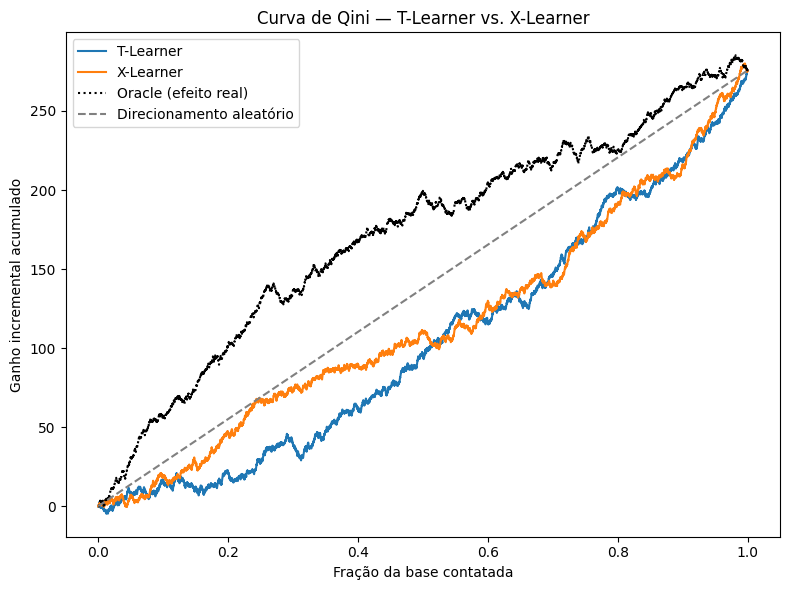

Neste dataset sintético o tratamento é 50/50, que é exatamente o cenário menos favorável para o X-Learner mostrar vantagem sobre o T-Learner (a motivação dele é justamente compensar grupos de tamanhos muito diferentes). Compare os p-valores acima: eles dizem se cada modelo bate um direcionamento aleatório com confiança estatística -- e não apenas qual dos dois tem o número de Qini mais alto.


In [27]:
plt.figure(figsize=(8, 6))
plt.plot(frac_model, qini_model, label="T-Learner")
plt.plot(frac_x, qini_x, label="X-Learner")
plt.plot(frac_oracle, qini_oracle, linestyle=":", color="black", label="Oracle (efeito real)")
plt.plot(frac_random, qini_random, linestyle="--", color="gray", label="Direcionamento aleatório")
plt.xlabel("Fração da base contatada")
plt.ylabel("Ganho incremental acumulado")
plt.title("Curva de Qini — T-Learner vs. X-Learner")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Neste dataset sintético o tratamento é 50/50, que é exatamente o cenário menos "
    "favorável para o X-Learner mostrar vantagem sobre o T-Learner (a motivação dele é "
    "justamente compensar grupos de tamanhos muito diferentes). Compare os p-valores "
    "acima: eles dizem se cada modelo bate um direcionamento aleatório com confiança "
    "estatística -- e não apenas qual dos dois tem o número de Qini mais alto."
)

## 19. O que aprendemos?

### Modelo de resposta

Responde:

> **Quem provavelmente compra?**

É útil para:

- priorização comercial
- recomendação
- previsão de demanda individual
- campanhas de aquisição

### Uplift Model

Responde:

> **Quem provavelmente compra por causa da intervenção?**

É útil para:

- campanhas de marketing
- descontos
- retenção
- cross-sell
- upsell
- priorização de vendedores
- alocação de orçamento

### Causal ML

Vai além da correlação e tenta estimar o efeito de uma intervenção.

A ideia fundamental é o **counterfactual**:

> O que teria acontecido com este mesmo cliente se ele não tivesse recebido a campanha?

Não observamos os dois mundos simultaneamente. Por isso desenho experimental, randomização e hipóteses causais são fundamentais — e por isso, nesta revisão, adicionamos a checagem de balanceamento covariável (Seção 3) como primeiro passo, antes de qualquer estimativa de efeito.

## 20. Próximos passos para um projeto real

Este notebook é propositalmente simples, mesmo após a revisão. Itens que já foram cobertos aqui (e que apareciam como "próximos passos" na versão anterior): **Qini Curve, Qini Coefficient, AUUC e CATE** (Seções 14-15), além de uma comparação inicial com **X-Learner** (Seção 18).

Em um projeto profissional eu ainda acrescentaria:

1. **A/B test bem desenhado**, com poder estatístico calculado a priori (tamanho de amostra por decil de uplift costuma exigir bases grandes)
2. Definição correta da janela de tratamento e do outcome (evitar contar como "conversão" uma compra que já estava agendada antes da campanha)
3. Controle de leakage (nenhuma variável pós-tratamento nas features)
4. Feature engineering temporal (tendência de compra, sazonalidade)
5. Cross-validation apropriada para o T-/X-Learner (hoje usamos um único split)
6. **Doubly Robust Learner** e **Causal Forest** — tendem a ter menor variância que T-/X-Learner e são hoje o padrão em bibliotecas como `econml` e `causalml`
7. Teste de significância do próprio Qini coefficient (ex.: via permutação), para saber se o modelo bate um direcionamento aleatório com confiança estatística, não só em ponto estimado
8. Em cenários **não randomizados**: estimar `e(X)` de verdade (Seção 7) e usar IPW ou doubly-robust em vez de comparação direta de médias
9. Análise de custos e ROI mais realista (margem variável por segmento, capacidade comercial limitada, saturação de desconto)
10. Monitoramento do modelo em produção: drift nas features, drift na calibração (Seção 7/9), e re-treinamento
11. Integração com CRM e com a régua de contato (evitar sobrepor esta campanha com outras ativas no mesmo cliente)

> **Regra prática:** não use uplift para simplesmente "achar segmentos". O objetivo é estimar **efeito incremental de uma ação** e transformar essa estimativa em uma decisão de negócio.

## 21. O que foi corrigido e adicionado nesta revisão

**Bugs / erros corrigidos:**

- `class_weight="balanced"` em todos os `RandomForestClassifier` (modelo de resposta e T-Learner): distorcia a calibração das probabilidades, o que é especialmente grave em uplift, já que o uplift é uma diferença de duas probabilidades.
- Splits de treino/teste diferentes entre o "modelo de propensão" e o T-Learner — unificados em um único split (Seção 6).
- Rótulo "quartil" usado para uma divisão em 10 grupos (na verdade decis) — corrigido para "decil".
- Lógica de `classify_uplift`: a ordem das condições originais podia classificar clientes com uplift alto como "Certo" apenas por terem `p_control` alto. Reescrita como quatro grupos mutuamente exclusivos, com thresholds derivados dos percentis da base (em vez de valores fixos).
- Confusão conceitual entre "propensity score" (`P(T=1|X)`, usado em métodos causais como IPW/matching) e "modelo de resposta" (`P(Y=1|X)`, o que o notebook original chamava de "propensity model"). Os dois agora aparecem, nomeados corretamente, na Seção 7.
- Imports não utilizados (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`) removidos; `LogisticRegression`, que estava importada mas nunca usada, agora serve de baseline comparável ao Random Forest.

**Adições:**

- Checagem de balanceamento covariável / randomização (SMD) — Seção 3.
- Intervalo de confiança e teste estatístico para o ATE — Seção 5.
- Curvas de calibração para o modelo de resposta e para os dois modelos do T-Learner — Seções 7 e 9.
- Estimativa do propensity score real `e(X)` — Seção 7.
- Comparação do uplift previsto por segmento com o efeito real (`uplift_true`) — Seção 11.
- Intervalos de confiança por decil na avaliação do ranking — Seção 13.
- Avaliação "oracle" completa contra o efeito causal verdadeiro (correlação, MAE, viés, calibração) — Seção 14, só possível por os dados serem sintéticos.
- Curva de Qini, Qini coefficient e AUUC — Seção 15 (estava só listado como "próximo passo" antes).
- Teste de permutação para o Qini coefficient (significância estatística, não só o valor pontual) — Seção 15.1, também listado como "próximo passo" no notebook original.
- X-Learner como segundo meta-learner, comparado ao T-Learner via Qini coefficient e via o mesmo teste de significância — Seção 18.

**Achado que vale destacar:** ao rodar esta versão revisada, o teste de permutação da Seção 15.1 mostra que, *neste holdout específico*, nem o T-Learner nem o X-Learner batem um direcionamento aleatório com confiança estatística — apesar de existir heterogeneidade real nos dados (Seção 14, via `uplift_true`) e de a correlação bruta com o efeito real ser positiva. Isso não é uma falha do notebook: é o tipo de resultado que só aparece quando se avalia um modelo de uplift com rigor (Qini + teste de significância) em vez de olhar só a métrica pontual, e é exatamente por isso que essas duas ferramentas deveriam ser padrão antes de decidir usar um modelo de uplift em produção.